importing the neccesary libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, classification_report, confusion_matrix

SEED = 42
np.random.seed(SEED)

now load the data

In [4]:
train= pd.read_csv("../data/train.csv")
public_test = pd.read_csv("../data/public_test.csv")
private_test = pd.read_csv("../data/private_test.csv")

In [5]:
print(train.shape)
print(public_test.shape)
print(private_test.shape)

(10000, 14)
(3000, 14)
(3000, 13)


In [6]:
print(train.head())

   User_ID   Age         Income  City_Tier Device_Type Traffic_Source  \
0        1  58.0  103593.708812          2      Mobile        Organic   
1        2  26.0   36451.716984          2      Mobile   Social Media   
2        3  19.0   30511.228700          3      Mobile       Referral   
3        4  48.0   87789.172342          3      Mobile          Email   
4        5  35.0  105229.249067          2      Mobile   Social Media   

   Pages_Viewed  Products_Viewed  Time_On_Site  Previous_Purchases  \
0             5                4          9.61                   3   
1            11                3         17.63                   2   
2             1                1         13.25                   5   
3            14               12           NaN                   1   
4            14               21         16.92                   1   

   Discount_Seen  Browser_Version  Campaign_Code  Converted  
0              0               11           2418          0  
1              0

now perform the eda

In [8]:
print(train.dtypes)
print(train.describe())
print(train.info())

User_ID                 int64
Age                   float64
Income                float64
City_Tier               int64
Device_Type            object
Traffic_Source         object
Pages_Viewed            int64
Products_Viewed         int64
Time_On_Site          float64
Previous_Purchases      int64
Discount_Seen           int64
Browser_Version         int64
Campaign_Code           int64
Converted               int64
dtype: object
           User_ID          Age         Income     City_Tier  Pages_Viewed  \
count  10000.00000  8520.000000    9016.000000  10000.000000   10000.00000   
mean    5000.50000    41.457746   69961.772797      1.933400      15.60850   
std     2886.89568    13.770164   24790.673822      0.737712       8.62346   
min        1.00000    18.000000   12000.000000      1.000000       1.00000   
25%     2500.75000    29.000000   52294.644359      1.000000       8.00000   
50%     5000.50000    41.000000   70171.613672      2.000000      16.00000   
75%     7500.25000  

check the number of missing values

In [9]:
print(train.isnull().sum())

User_ID                  0
Age                   1480
Income                 984
City_Tier                0
Device_Type              0
Traffic_Source           0
Pages_Viewed             0
Products_Viewed          0
Time_On_Site          1848
Previous_Purchases       0
Discount_Seen            0
Browser_Version          0
Campaign_Code            0
Converted                0
dtype: int64


In [10]:
# check for target class proportions to see if there is class imbalance
print(train["Converted"].value_counts())
print(train['Converted'].value_counts(normalize=True).round(3))


Converted
0    6913
1    3087
Name: count, dtype: int64
Converted
0    0.691
1    0.309
Name: proportion, dtype: float64


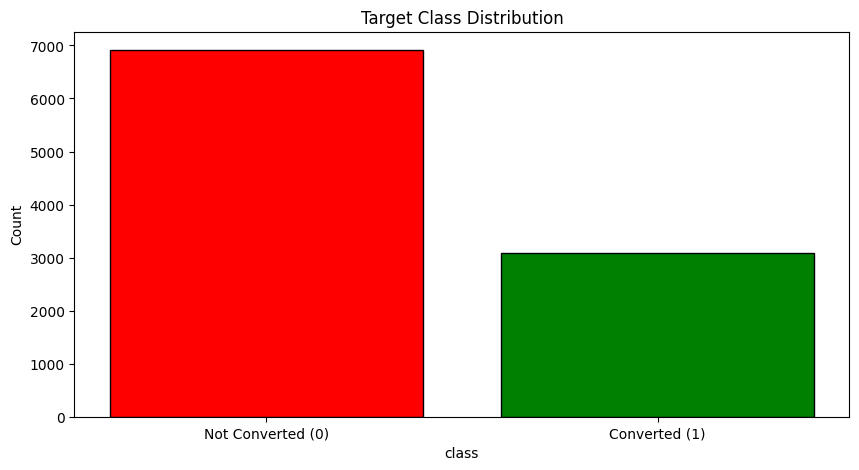

In [11]:
#make plot to see class proportions

plt.figure(figsize=(10,5))

counts = train['Converted'].value_counts()
plt.bar(['Not Converted (0)','Converted (1)'],counts.values, color=['red', 'green'],edgecolor='black')
plt.title('Target Class Distribution')
plt.ylabel('Count')
plt.xlabel("class")
plt.show()


Observation: Dataset is imbalanced that is ~31% converted and ~69% not converted.
We will handle this with class_weight='balanced' in Logistic Regression.

In [ ]:
# now we will see the distribution of numeric features by conversion status

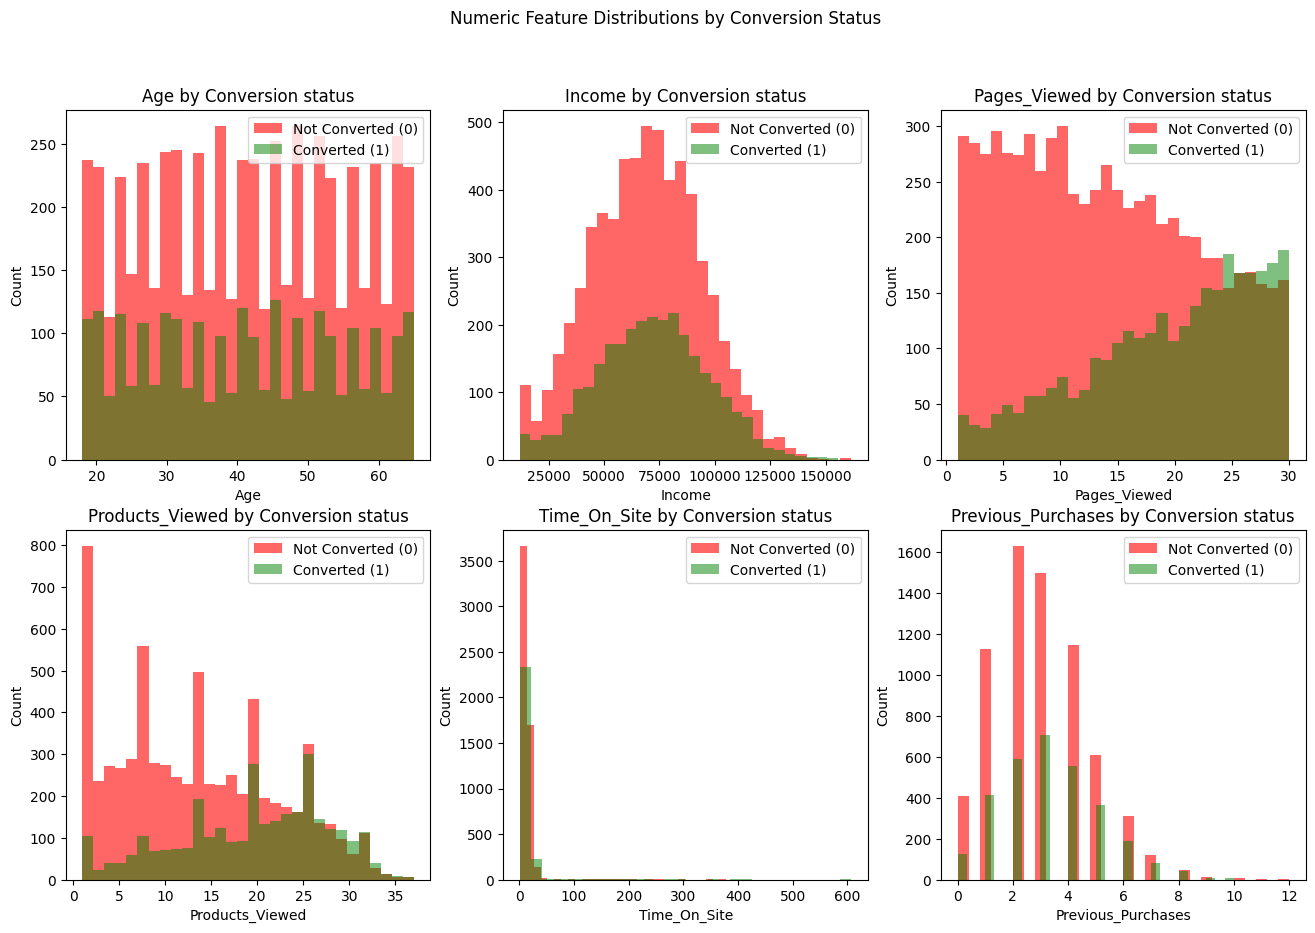

In [15]:
numeric_features = ['Age', 'Income', 'Pages_Viewed', 'Products_Viewed','Time_On_Site', 'Previous_Purchases']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    data0 = train[train['Converted']== 0][col].dropna()
    data1 = train[train['Converted']== 1][col].dropna()
    axes[i].hist(data0,bins=30, alpha=0.6,color='red',label='Not Converted (0)')
    axes[i].hist(data1, bins=30,alpha=0.5, color='green',label='Converted (1)')
    axes[i].set_title(f'{col} by Conversion status')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].legend()

plt.suptitle('Numeric Feature Distributions by Conversion Status',)
plt.show()

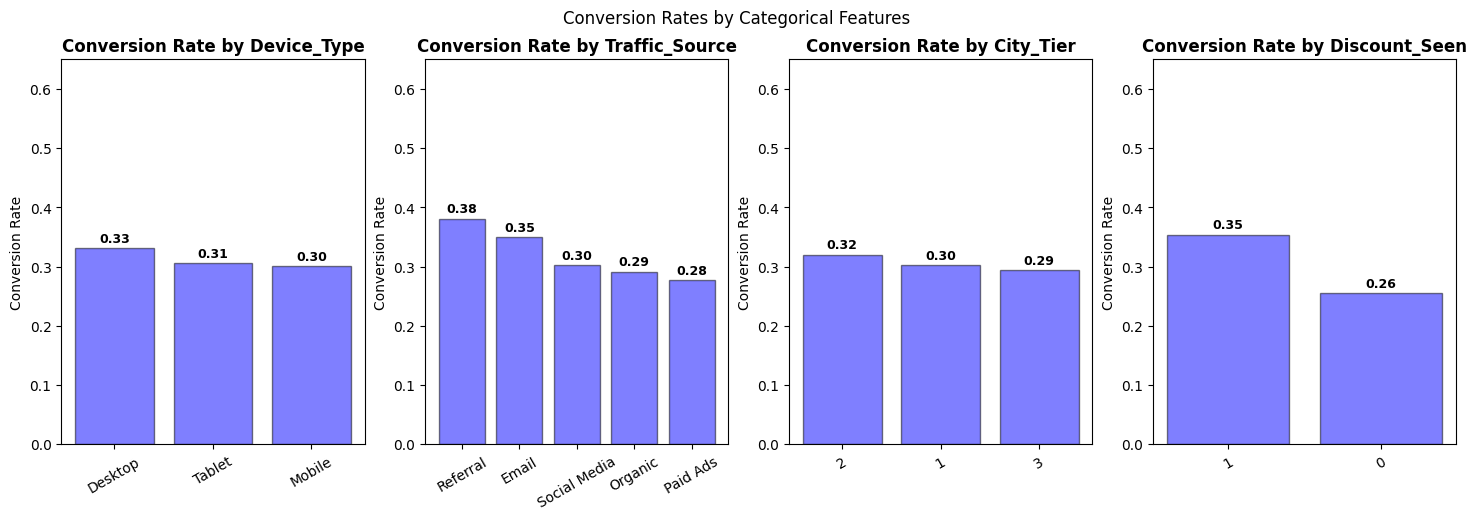

In [18]:
# now distribution of categorical fetaures by conversion status
cat_features = ['Device_Type', 'Traffic_Source', 'City_Tier', 'Discount_Seen']
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for i, col in enumerate(cat_features):
    conv_rate = train.groupby(col)['Converted'].mean().sort_values(ascending=False)
    bars = axes[i].bar(conv_rate.index.astype(str), conv_rate.values,color='blue',alpha=0.5,edgecolor='black')
    axes[i].set_title(f'Conversion Rate by {col}', fontweight='bold')
    axes[i].set_ylabel('Conversion Rate')
    axes[i].set_ylim(0, 0.65)
    axes[i].tick_params(axis='x', rotation=30)
    for bar, val in zip(bars, conv_rate.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, val + 0.01,f'{val:.2f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Conversion Rates by Categorical Features')
plt.show()

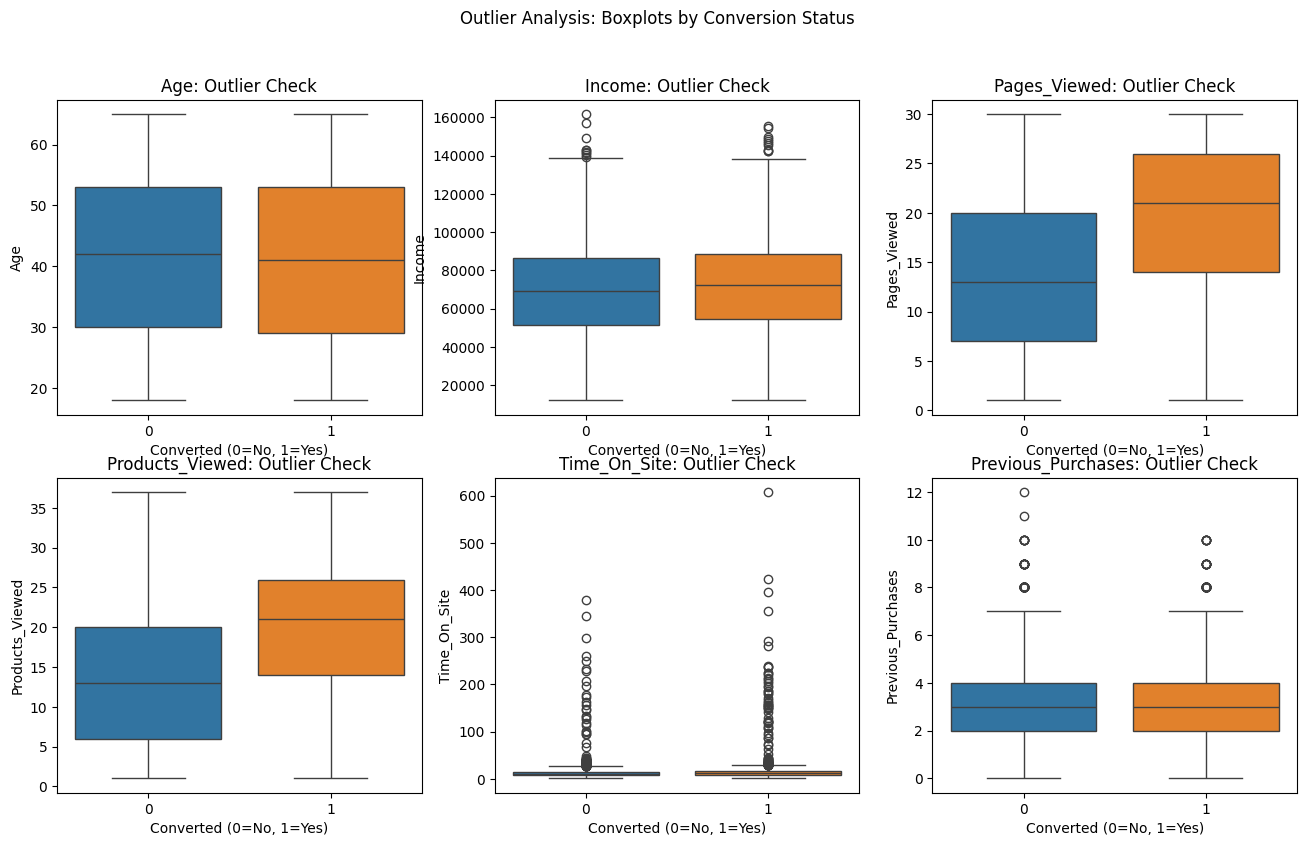

Observation: Outliers are present but we will use median imputation and StandardScaler which reduces their influence on Logistic Regression.


In [20]:
# now plot for outlier detection
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    sns.boxplot(data=train, x='Converted', y=col, ax=axes[i],hue='Converted',legend=False)
    axes[i].set_title(f'{col}: Outlier Check')
    axes[i].set_xlabel('Converted (0=No, 1=Yes)')

plt.suptitle('Outlier Analysis: Boxplots by Conversion Status')
plt.show()

print("Observation: Outliers are present but we will use median imputation and StandardScaler which reduces their influence on Logistic Regression.")

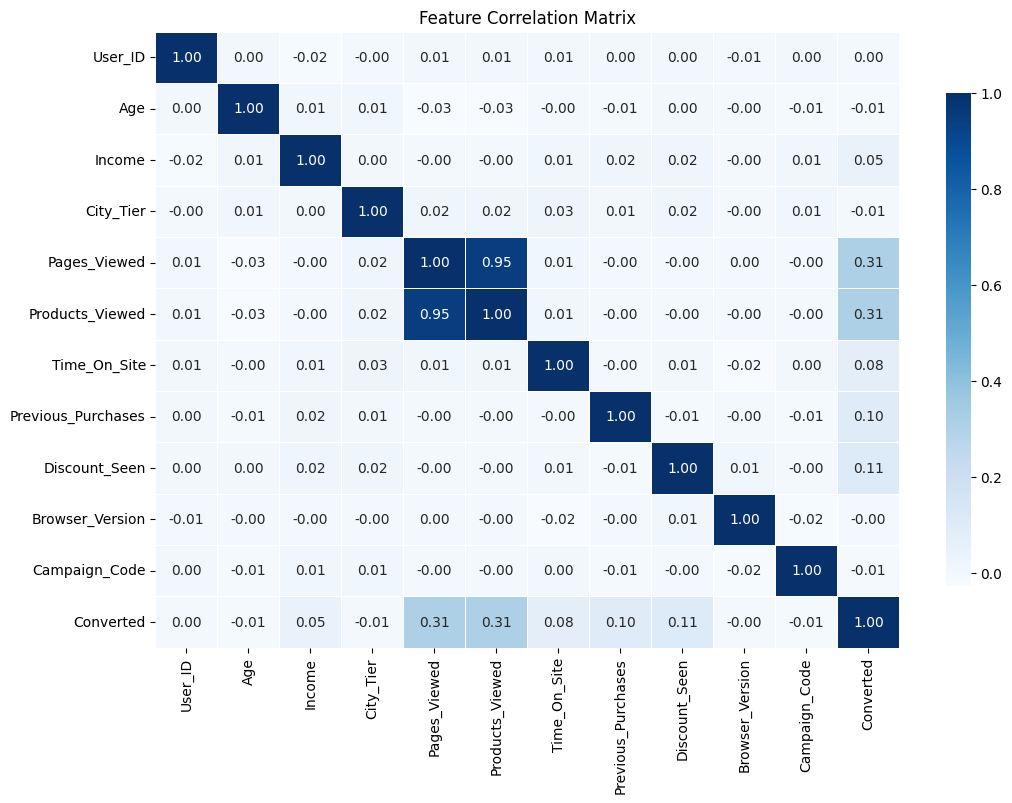

In [22]:
# plot for correlation heatmap
plt.figure(figsize=(12, 8))
numeric_cols = train.select_dtypes(include=['int64', 'float64']).columns.tolist()
corr_matrix = train[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='Blues', linewidths=0.5,cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix')
plt.show()


In [24]:
# now data preprocessing in which we will do the following:
# 1) handle missing values
# 2) do encoding for categorical values
# 3) handle the class imbalance so that that equal importance is given to minority class

TARGET = 'Converted'

# Merge train + public_test to maximize labeled training data
full_train = pd.concat([train, public_test], ignore_index=True)

print(f"Original train rows:{len(train)}")
print(f"Public test rows (labeled):{len(public_test)}")
print(f"Combined training rows:{len(full_train)}")
print(f"Private test rows:{len(private_test)}(no labels,we have to predict these)")

print("Combined class balance:")
print(full_train[TARGET].value_counts())
print(full_train[TARGET].value_counts(normalize=True).round(3))

Original train rows:10000
Public test rows (labeled):3000
Combined training rows:13000
Private test rows:3000(no labels,we have to predict these)
Combined class balance:
Converted
0    9027
1    3973
Name: count, dtype: int64
Converted
0    0.694
1    0.306
Name: proportion, dtype: float64


In [27]:
# now combine all the data to do consistent label encoding
all_data = pd.concat([full_train, private_test], ignore_index=True)

labelenc_device = LabelEncoder()
labelenc_traffic = LabelEncoder()

all_data['Device_Type_enc'] = labelenc_device.fit_transform(all_data['Device_Type'])
all_data['Traffic_Source_enc'] = labelenc_traffic.fit_transform(all_data['Traffic_Source'])

print("Device_Type mapping:",dict(zip(labelenc_device.classes_, labelenc_device.transform(labelenc_device.classes_))))
print("Traffic_Source mapping:",dict(zip(labelenc_traffic.classes_, labelenc_traffic.transform(labelenc_traffic.classes_))))

Device_Type mapping: {'Desktop': np.int64(0), 'Mobile': np.int64(1), 'Tablet': np.int64(2)}
Traffic_Source mapping: {'Email': np.int64(0), 'Organic': np.int64(1), 'Paid Ads': np.int64(2), 'Referral': np.int64(3), 'Social Media': np.int64(4)}


In [28]:
# now doing feature enginnering that is creating meaningful features

# first feature is engagement score - A user who viewed many products in a short time is likely more interested than someone who browsed casually
# Engagement_Score= Pages × Products × (Time + 1) ,, significance is that High score means: viewed many pages, explored many products, stayed for a long time...these users have more tendency to convert

all_data['Engagement_Score'] = all_data['Pages_Viewed'] * all_data['Products_Viewed'] * (all_data['Time_On_Site'] + 1)


In [31]:
# next feature is products per page = Products_Viewed / (Pages_Viewed + 1)
# significance: High ratio: User explored products efficiently and with purpose so most likely to be converted and Low ratio:User casually browsed pages so less likely to be converted
all_data['Products_Per_Page']= all_data['Products_Viewed']/(all_data['Pages_Viewed'] + 1)

In [32]:
# next fetaure is time per page= Time_On_Site / (Pages_Viewed + 1)
#significance- High value:User spent a lot of time on each page.This can indicate serious interest.Low value:User clicked through pages quickly thus less likely to be converted
all_data['Time_Per_Page'] = all_data['Time_On_Site'] / (all_data['Pages_Viewed'] + 1)

In [33]:
#next feature is pages*products=Pages_Viewed * Products_Viewed . It will capture deep browsing behavior.High values indicate strong purchase intent.
all_data['Pages_x_Products'] = all_data['Pages_Viewed'] * all_data['Products_Viewed']

In [34]:
#next feature is to capture ratio of loyal customers
#Is_Returning = 1 if Previous_Purchases > 0 else 0 . Significance: Returning customers usually trust the website more.Trust often increases conversions.
all_data['Is_Returning']= (all_data['Previous_Purchases'] > 0).astype(int)


In [35]:
# next fetaure is discount loyal= Discount_Seen * Is_Returning. This feature captures:Returning customer + saw discount.This combination has very high conversion probability.
all_data['Discount_Loyal'] = all_data['Discount_Seen'] * all_data['Is_Returning']

In [36]:
# next is Discount_x_Pages = Discount_Seen * Pages_Viewed. It measures that did the user continue browsing after seeing a discount? High values can indicate:User became more engaged because of the discount.
all_data['Discount_x_Pages'] = all_data['Discount_Seen'] * all_data['Pages_Viewed']

In [37]:
# next feature is Previous_x_Discount = Previous_Purchases * Discount_Seen. It will capture loyal customer who also saw a discount.This combination is also very predictive of conversion.
all_data['Previous_x_Discount'] = all_data['Previous_Purchases'] * all_data['Discount_Seen']

In [38]:
# now feature to capture demographic or economic aspects
# Income_Per_Age = Income / (Age + 1)
#Significance:Same income can mean different purchasing power depending on age.
#This feature will capture financial strength relative to life stage.
all_data['Income_Per_Age'] = all_data['Income'] / (all_data['Age'] + 1)


In [41]:
# transform the features to their logs to reduce right skew produced due to outliers .It will make the distribution more balanced so that model performs better
all_data['Log_Income'] = np.log(1+(all_data['Income'].fillna(0)))
all_data['Log_Time'] = np.log(1+(all_data['Time_On_Site'].fillna(0)))
all_data['Log_Engagement'] = np.log(1+(np.abs(all_data['Income'].fillna(0))))


In [42]:
# total cpoulmns after faeture engineering
print(all_data.shape)

(16000, 28)


In [46]:
# now define the final features set and split the data into train and test
DROP_COLS = ['User_ID', 'Device_Type', 'Traffic_Source', TARGET]
feature_cols = [c for c in all_data.columns if c not in DROP_COLS]
print("features:",feature_cols)


features: ['Age', 'Income', 'City_Tier', 'Pages_Viewed', 'Products_Viewed', 'Time_On_Site', 'Previous_Purchases', 'Discount_Seen', 'Browser_Version', 'Campaign_Code', 'Device_Type_enc', 'Traffic_Source_enc', 'Engagement_Score', 'Products_Per_Page', 'Time_Per_Page', 'Pages_x_Products', 'Is_Returning', 'Discount_Loyal', 'Discount_x_Pages', 'Previous_x_Discount', 'Income_Per_Age', 'Log_Income', 'Log_Time', 'Log_Engagement']


In [47]:
# split the data into training and test data
n_full = len(full_train)
train_final = all_data.iloc[:n_full]
test_final= all_data.iloc[n_full:]

X = train_final[feature_cols].values
y = train_final[TARGET].values
X_test = test_final[feature_cols].values



In [48]:
# handle missing values by median imputation which is most suitable in case of outliers
# NOTE: fit on training data only, then apply to private test.Fitting on both would cause data leakage.
imputer=SimpleImputer(strategy="median")
X_imp = imputer.fit_transform(X) # find median and replace nan by median
X_test_imp = imputer.transform(X_test) # use the same median learnt from training data...don't use test data to learn medians



In [49]:
# now do feature scaling to normalise the values of features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imp)
X_test_scaled= scaler.transform(X_test_imp)

In [51]:
print("training data shape",X_scaled.shape)
print("test data shape",X_test_scaled.shape)

training data shape (13000, 24)
test data shape (3000, 24)


In [54]:
# now train the model- Logistic Regression
# we have already observed that there is class imbalnce in data as non converted percenatge is 69.4% and converted is 30.6%
# so we will use class_weight="balanced in logistic regression to handle this

model = LogisticRegression(max_iter=1000,random_state=SEED,
    class_weight='balanced', # handles class imbalance
    C=0.1 # regularization to prevent overfitting
)
                           

In [58]:
# now use startified 5 fold cross validation to find the optimal threshold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_f1_scores = []
best_thresholds = []
for fold, (tr_idx, val_idx) in enumerate(cv.split(X_scaled, y)):
    X_tr, X_val = X_scaled[tr_idx], X_scaled[val_idx]
    y_tr, y_val = y[tr_idx], y[val_idx]

    #Train
    model.fit(X_tr, y_tr)
    #Get predicted probabilities
    probs = model.predict_proba(X_val)[:, 1]

    #Find optimal threshold for F1 score
    best_f1, best_threshold = 0, 0.5 #initialise
    for threshold in np.arange(0.20, 0.80, 0.01):
        preds = (probs >= threshold).astype(int)
        score = f1_score(y_val, preds)
        if score > best_f1:
            best_f1 = score
            best_threshold = threshold

    best_thresholds.append(best_threshold)
    cv_f1_scores.append(best_f1)    
    print(f" Fold {fold+1}:F1 = {best_f1:.4f} , Optimal Threshold = {best_threshold:.2f}")

    
    


 Fold 1:F1 = 0.5783 , Optimal Threshold = 0.50
 Fold 2:F1 = 0.5560 , Optimal Threshold = 0.47
 Fold 3:F1 = 0.5590 , Optimal Threshold = 0.43
 Fold 4:F1 = 0.5654 , Optimal Threshold = 0.41
 Fold 5:F1 = 0.5664 , Optimal Threshold = 0.42


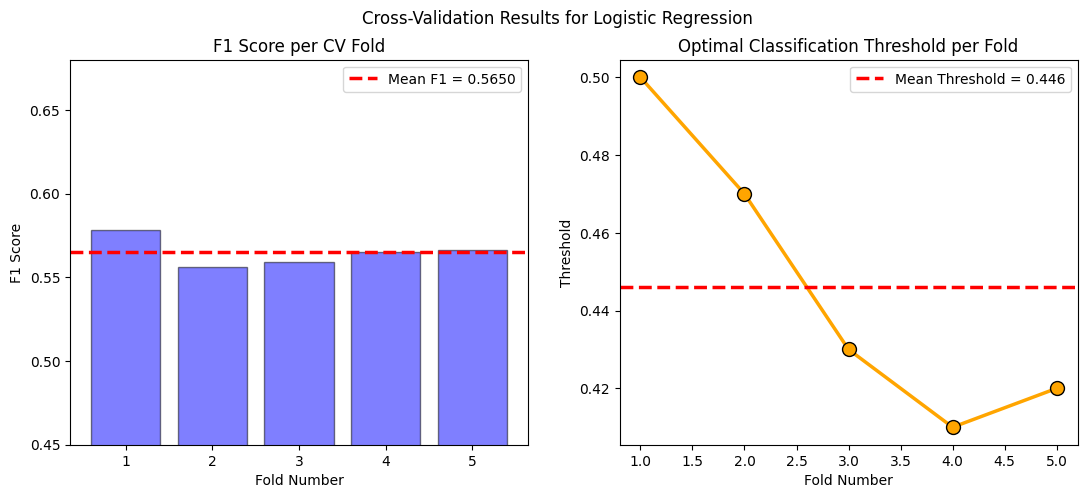

In [56]:
# plots to visualise the cv results

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# F1 per fold
bars = axes[0].bar(range(1, 6), cv_f1_scores, color='blue',alpha=0.5,edgecolor='black')
axes[0].axhline(np.mean(cv_f1_scores), color='red', linestyle='--',linewidth=2.5, label=f'Mean F1 = {np.mean(cv_f1_scores):.4f}')
axes[0].set_title('F1 Score per CV Fold')
axes[0].set_xlabel('Fold Number')
axes[0].set_ylabel('F1 Score')
axes[0].set_ylim(0.45, 0.68)
axes[0].legend()

# Optimal threshold per fold
axes[1].plot(range(1, 6), best_thresholds, 'o-', color='orange',linewidth=2.5, markersize=10, markeredgecolor='black')
axes[1].axhline(np.mean(best_thresholds), color='red', linestyle='--',linewidth=2.5, label=f'Mean Threshold = {np.mean(best_thresholds):.3f}')
axes[1].set_title('Optimal Classification Threshold per Fold')
axes[1].set_xlabel('Fold Number')
axes[1].set_ylabel('Threshold')
axes[1].legend()

plt.suptitle('Cross-Validation Results for Logistic Regression')
plt.show()



                Feature  Coefficient
3          Pages_Viewed     0.656176
7         Discount_Seen     0.487534
4       Products_Viewed     0.422753
6    Previous_Purchases     0.277333
5          Time_On_Site     0.263917
22             Log_Time     0.188924
12     Engagement_Score    -0.167327
15     Pages_x_Products    -0.163356
18     Discount_x_Pages    -0.127502
17       Discount_Loyal    -0.097547
10      Device_Type_enc    -0.067182
1                Income     0.066776
20       Income_Per_Age     0.054123
2             City_Tier    -0.046106
23       Log_Engagement     0.044166
21           Log_Income     0.044166
0                   Age     0.041677
9         Campaign_Code    -0.018325
13    Products_Per_Page     0.015068
11   Traffic_Source_enc     0.012934
14        Time_Per_Page    -0.005636
8       Browser_Version    -0.005211
19  Previous_x_Discount    -0.005067
16         Is_Returning     0.000733


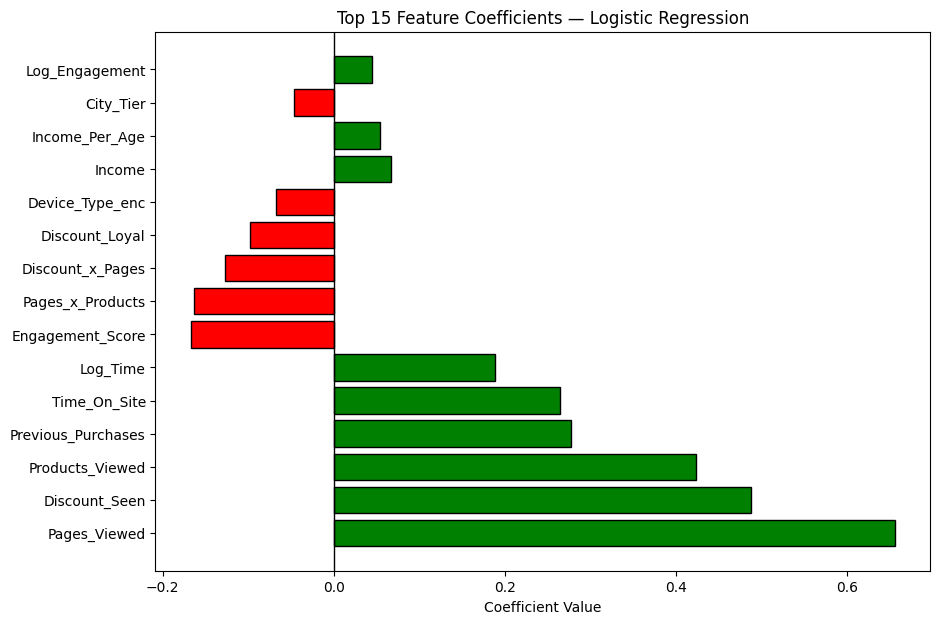

In [60]:
# now see feature importances using full original training dataset
model.fit(X_scaled, y)

coef_df = pd.DataFrame({'Feature': feature_cols,'Coefficient': model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)
print(coef_df)
plt.figure(figsize=(10, 7))
top_features = coef_df.head(15)
colors = ['green' if v > 0 else 'red' for v in top_features['Coefficient']]
plt.barh(top_features['Feature'], top_features['Coefficient'],color=colors, edgecolor='black')
plt.axvline(0, color='black', linewidth=1)
plt.title('Top 15 Feature Coefficients — Logistic Regression')
plt.xlabel('Coefficient Value')
plt.show()


In [62]:
# make the predictions
# Final threshold = mean of all CV optimal thresholds
FINAL_THRESHOLD = np.mean(best_thresholds)
print(f"Final Classification Threshold: {FINAL_THRESHOLD:.3f}")

# Predict probabilities on test data
final_probs = model.predict_proba(X_test_scaled)[:, 1]

# Apply threshold
final_predictions = (final_probs >= FINAL_THRESHOLD).astype(int)

print(f"Total predictions:{len(final_predictions):,}")
print(f"Predicted Converted=1: {final_predictions.sum()} ({final_predictions.mean()*100:.1f}%)")
print(f"Predicted Converted=0: {(1-final_predictions).sum()} ({(1-final_predictions).mean()*100:.1f}%)")


Final Classification Threshold: 0.446
Total predictions:3,000
Predicted Converted=1: 1564 (52.1%)
Predicted Converted=0: 1436 (47.9%)


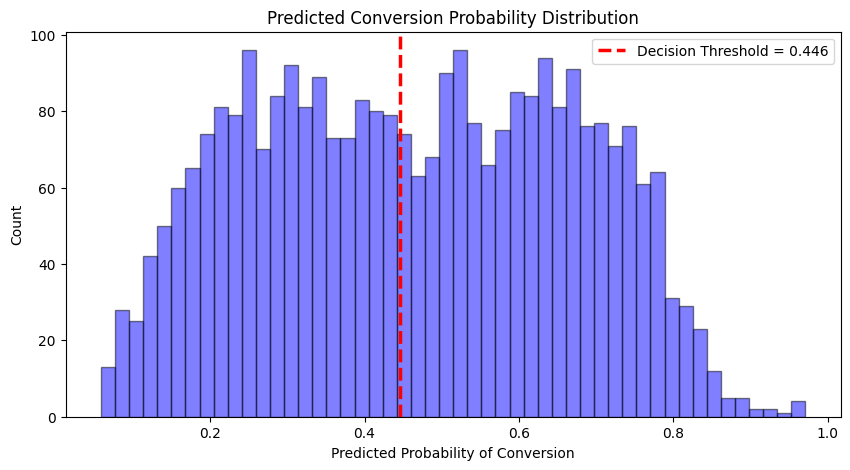

In [64]:
# visualise the prediction results
plt.figure(figsize=(10, 5))
plt.hist(final_probs, bins=50, color='blue', edgecolor='black', alpha=0.5)
plt.axvline(FINAL_THRESHOLD, color='red', linestyle='--', linewidth=2.5,label=f'Decision Threshold = {FINAL_THRESHOLD:.3f}')
plt.title('Predicted Conversion Probability Distribution')
plt.xlabel('Predicted Probability of Conversion')
plt.ylabel('Count')
plt.legend()
plt.show()

In [68]:
# Create submission DataFrame
submission = pd.DataFrame({'User_ID': private_test['User_ID'],'Converted': final_predictions})

submission.to_csv('submission.csv', index=False)
print(f"Shape: {submission.shape}")
submission.head(10)

Shape: (3000, 2)


,User_ID,Converted
0,103001,0
1,103002,0
2,103003,1
3,103004,1
4,103005,0
5,103006,1
6,103007,1
7,103008,0
8,103009,0
9,103010,0


In [71]:
print(submission.isnull().sum())

User_ID      0
Converted    0
dtype: int64
